# Random Forest — PM2.5 Tashkent
Step-by-step: load data → train → metrics → plots → save

## 1. Imports and configuration

In [1]:
import json
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

BASE       = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR   = os.path.join(BASE, 'data')
MODELS_DIR = os.path.join(BASE, 'models')
OUT_DIR    = os.path.join(BASE, 'outputs', 'rf_analysis')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUT_DIR,    exist_ok=True)

print('Ready.')

Ready.


## 2. Load data

In [2]:
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'), parse_dates=['datetime'])
test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'),  parse_dates=['datetime'])

with open(os.path.join(DATA_DIR, 'feature_cols.json')) as f:
    feature_cols = json.load(f)

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'Features: {len(feature_cols)}')
print('\nFeature list:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2}. {col}')

Train : (16928, 28)
Test  : (4233, 28)
Features: 25

Feature list:
   1. temperature_2m
   2. relative_humidity_2m
   3. wind_speed_10m
   4. wind_direction_10m
   5. surface_pressure
   6. precipitation
   7. pm25_lag_1h
   8. pm25_lag_2h
   9. pm25_lag_3h
  10. pm25_lag_6h
  11. pm25_lag_12h
  12. pm25_lag_24h
  13. pm25_lag_48h
  14. pm25_roll_3h
  15. pm25_roll_6h
  16. pm25_roll_24h
  17. pm25_roll_7d
  18. hour_sin
  19. hour_cos
  20. dow_sin
  21. dow_cos
  22. month_sin
  23. month_cos
  24. wind_u
  25. wind_v


## 3. Target (PM2.5) statistics

In [3]:
print('=== Train PM2.5 statistics ===')
print(train['pm25'].describe().round(2))
print('\n=== Test PM2.5 statistics ===')
print(test['pm25'].describe().round(2))

=== Train PM2.5 statistics ===
count    16928.00
mean        32.03
std         38.29
min          0.00
25%          9.30
50%         17.00
75%         38.51
max        249.21
Name: pm25, dtype: float64

=== Test PM2.5 statistics ===
count    4233.00
mean       25.23
std        25.12
min         0.25
25%        10.70
50%        16.80
75%        27.80
max       224.95
Name: pm25, dtype: float64


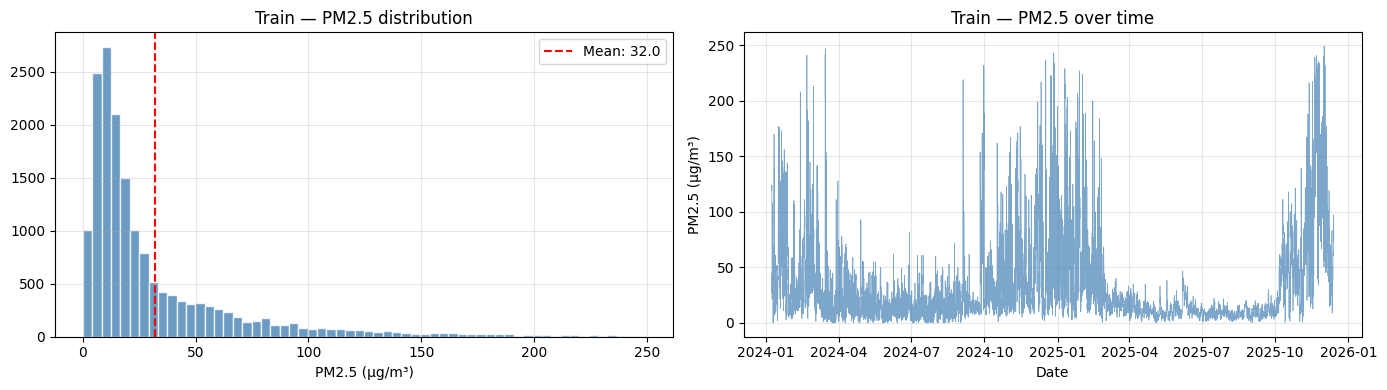

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution histogram
axes[0].hist(train['pm25'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(train['pm25'].mean(), color='red', linestyle='--',
                label=f"Mean: {train['pm25'].mean():.1f}")
axes[0].set_title('Train — PM2.5 distribution')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].legend()

# Time series
axes[1].plot(train['datetime'], train['pm25'], linewidth=0.5, color='steelblue', alpha=0.7)
axes[1].set_title('Train — PM2.5 over time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '01_pm25_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Split features and target

In [5]:
X_train = train[feature_cols].values
y_train = train['pm25'].values
X_test  = test[feature_cols].values
y_test  = test['pm25'].values

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

# Sanity check — no NaNs should remain after preprocessing
print(f'X_train NaN: {np.isnan(X_train).sum()}')
print(f'X_test  NaN: {np.isnan(X_test).sum()}')

X_train : (16928, 25)
X_test  : (4233, 25)
X_train NaN: 0
X_test  NaN: 0


## 5. Train Random Forest

In [6]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,       # use all CPU cores
    random_state=42,
)

print('Training Random Forest... (1-3 minutes)')
t0 = time.time()
rf.fit(X_train, y_train)
elapsed = time.time() - t0
print(f'Done. Time: {elapsed:.1f}s')

Training Random Forest... (1-3 minutes)
Done. Time: 2.8s


## 6. Predictions and metrics

In [10]:
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

# Train metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train  = mean_absolute_error(y_train, y_pred_train)
r2_train   = r2_score(y_train, y_pred_train)

# Test metrics
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test   = mean_absolute_error(y_test, y_pred_test)
r2_test    = r2_score(y_test, y_pred_test)

print('=' * 42)
print(f'{"Metric":<12} {"Train":>12} {"Test":>12}')
print('-' * 42)
print(f'{"RMSE":<12} {rmse_train:>12.3f} {rmse_test:>12.3f}')
print(f'{"MAE":<12} {mae_train:>12.3f} {mae_test:>12.3f}')
print(f'{"R2":<12} {r2_train:>12.4f} {r2_test:>12.4f}')
print('=' * 42)

# Target thresholds from project plan
print(f'\nTarget: RMSE < 15, R2 > 0.85')
print(f'RMSE test : {rmse_test:.2f} => {"PASS" if rmse_test < 15 else "FAIL"}')
print(f'R2   test : {r2_test:.4f} => {"PASS" if r2_test > 0.85 else "FAIL"}')

Metric              Train         Test
------------------------------------------
RMSE                6.645        7.328
MAE                 3.148        3.505
R2                 0.9699       0.9149

Target: RMSE < 15, R2 > 0.85
RMSE test : 7.33 => PASS
R2   test : 0.9149 => PASS


## 7. Actual vs Predicted plots

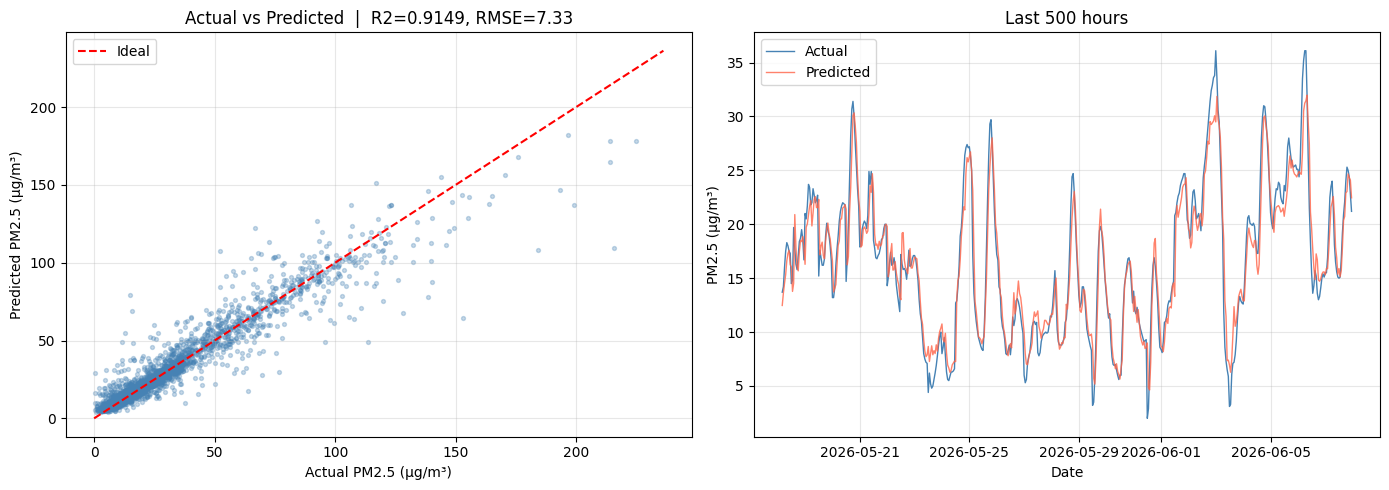

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot — ideal line is y=x
ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.3, s=8, color='steelblue')
lim_max = max(y_test.max(), y_pred_test.max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], 'r--', linewidth=1.5, label='Ideal')
ax.set_xlabel('Actual PM2.5 (µg/m³)')
ax.set_ylabel('Predicted PM2.5 (µg/m³)')
ax.set_title(f'Actual vs Predicted  |  R2={r2_test:.4f}, RMSE={rmse_test:.2f}')
ax.legend()

# Time series — last 500 hours for readability
ax = axes[1]
n = 500
dates = test['datetime'].iloc[-n:]
ax.plot(dates, y_test[-n:],      label='Actual',    linewidth=1, color='steelblue')
ax.plot(dates, y_pred_test[-n:], label='Predicted', linewidth=1, color='tomato', alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Last 500 hours')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '02_actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Residuals analysis

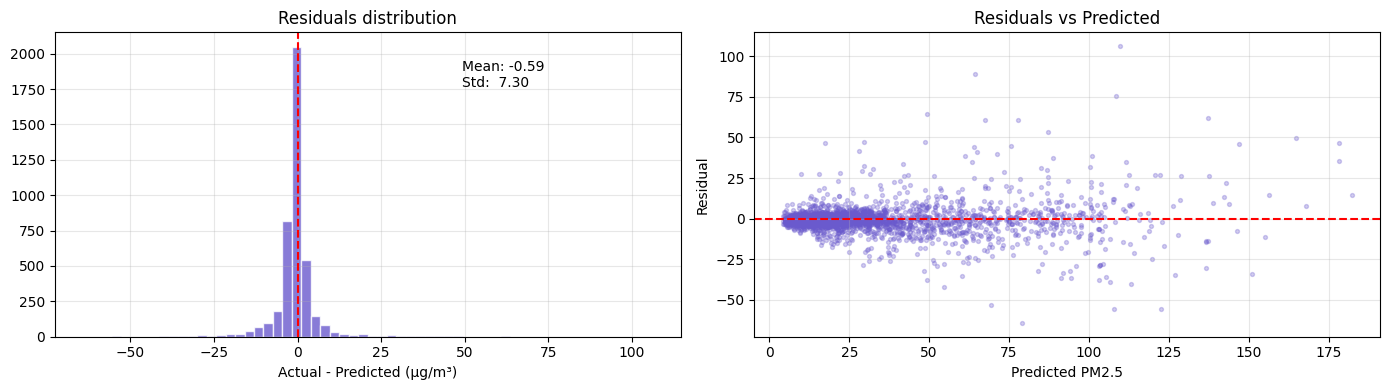

Mean : -0.589  (should be close to 0)
Std  : 7.305
Min  : -64.106
Max  : 106.086


In [12]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals histogram — should be approximately normal and centered at 0
axes[0].hist(residuals, bins=60, color='slateblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals distribution')
axes[0].set_xlabel('Actual - Predicted (µg/m³)')
axes[0].annotate(f'Mean: {residuals.mean():.2f}\nStd:  {residuals.std():.2f}',
                 xy=(0.65, 0.82), xycoords='axes fraction', fontsize=10)

# Residuals vs Predicted — check for heteroscedasticity
axes[1].scatter(y_pred_test, residuals, alpha=0.3, s=8, color='slateblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '03_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean : {residuals.mean():.3f}  (should be close to 0)')
print(f'Std  : {residuals.std():.3f}')
print(f'Min  : {residuals.min():.3f}')
print(f'Max  : {residuals.max():.3f}')

## 9. Feature importance (top 15)

Top 15 features:
             feature  importance
         pm25_lag_1h    0.281339
        pm25_roll_3h    0.151122
         pm25_lag_2h    0.132668
        pm25_roll_6h    0.094737
       pm25_roll_24h    0.081029
         pm25_lag_3h    0.072076
         pm25_lag_6h    0.036365
        pm25_lag_24h    0.024248
        pm25_roll_7d    0.022254
        pm25_lag_12h    0.016686
        pm25_lag_48h    0.014474
      temperature_2m    0.012291
    surface_pressure    0.010611
relative_humidity_2m    0.008397
      wind_speed_10m    0.006051


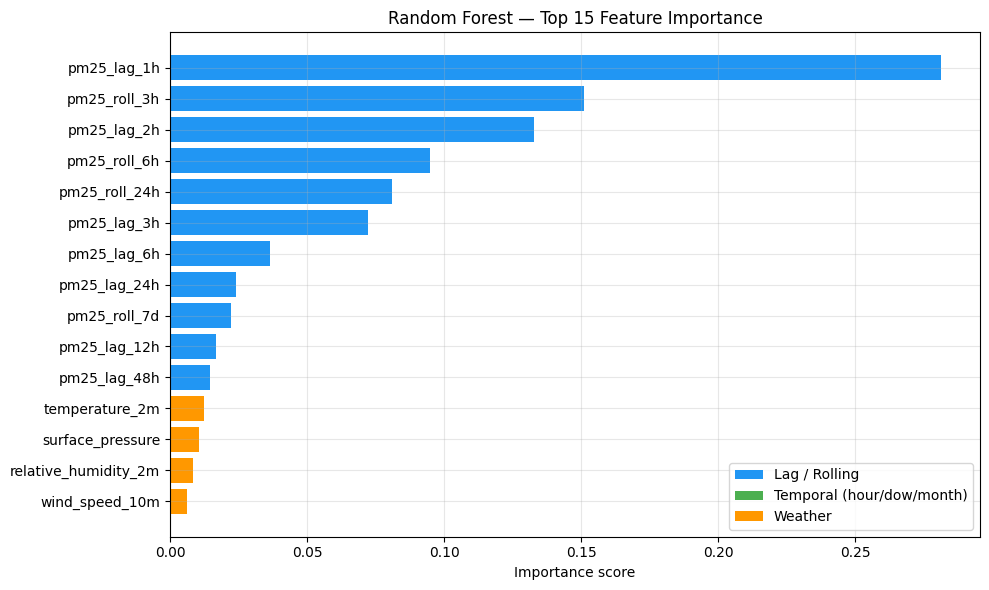

In [13]:
importances = rf.feature_importances_
fi = pd.DataFrame({'feature': feature_cols, 'importance': importances})
fi = fi.sort_values('importance', ascending=False).head(15).reset_index(drop=True)

print('Top 15 features:')
print(fi.to_string(index=False))

# Color by feature category
colors = ['#2196F3' if ('lag' in f or 'roll' in f) else
          '#4CAF50' if any(w in f for w in ['hour', 'dow', 'month']) else
          '#FF9800'
          for f in fi['feature']]

plt.figure(figsize=(10, 6))
plt.barh(fi['feature'][::-1], fi['importance'][::-1], color=colors[::-1])
plt.xlabel('Importance score')
plt.title('Random Forest — Top 15 Feature Importance')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Lag / Rolling'),
    Patch(facecolor='#4CAF50', label='Temporal (hour/dow/month)'),
    Patch(facecolor='#FF9800', label='Weather'),
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Largest prediction errors

In [14]:
test_copy = test.copy()
test_copy['y_pred'] = y_pred_test
test_copy['error']  = np.abs(y_test - y_pred_test)

big_errors = test_copy.nlargest(10, 'error')[['datetime', 'pm25', 'y_pred', 'error']]
big_errors.columns = ['Date', 'Actual', 'Predicted', 'Abs Error']
big_errors = big_errors.round(2)

print('Top 10 largest prediction errors:')
print(big_errors.to_string(index=False))

Top 10 largest prediction errors:
                     Date  Actual  Predicted  Abs Error
2026-01-09 06:00:00+00:00  215.82     109.73     106.09
2026-01-10 20:00:00+00:00  152.93      64.26      88.67
2025-12-19 07:00:00+00:00  184.11     108.48      75.63
2025-12-28 08:00:00+00:00  113.68      49.27      64.41
2025-12-21 23:00:00+00:00   15.00      79.11      64.11
2025-12-19 18:00:00+00:00  199.05     137.26      61.78
2026-01-02 12:00:00+00:00  128.25      67.44      60.81
2025-12-24 02:00:00+00:00  138.60      77.87      60.74
2025-12-24 03:00:00+00:00   66.77     122.45      55.68
2026-01-02 15:00:00+00:00   52.27     107.76      55.49


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7764\420598772.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  big_errors = big_errors.round(2)


## 11. Monthly RMSE breakdown

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7764\2891898929.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  test_copy['month'] = test_copy['datetime'].dt.to_period('M')


Monthly metrics:
  month  RMSE   MAE     R2     n
2025-12 15.83 10.83 0.8486 441.0
2026-01 11.68  6.99 0.8408 744.0
2026-02  2.66  2.04 0.8755 672.0
2026-03  2.76  1.93 0.9097 744.0
2026-04  1.60  1.18 0.9088 720.0
2026-05  1.69  1.23 0.9173 744.0
2026-06  2.27  1.73 0.8970 168.0


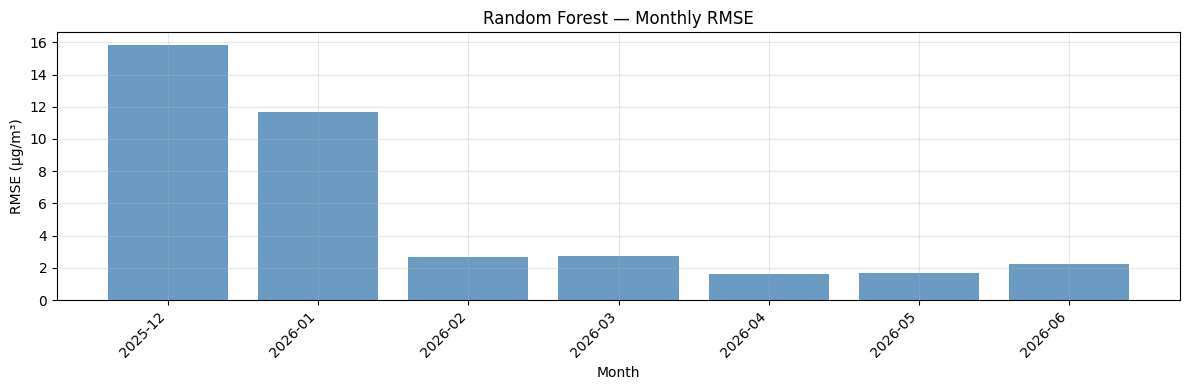

In [15]:
test_copy['month'] = test_copy['datetime'].dt.to_period('M')
monthly = test_copy.groupby('month').apply(
    lambda g: pd.Series({
        'RMSE': round(np.sqrt(mean_squared_error(g['pm25'], g['y_pred'])), 2),
        'MAE':  round(mean_absolute_error(g['pm25'], g['y_pred']), 2),
        'R2':   round(r2_score(g['pm25'], g['y_pred']), 4) if len(g) > 1 else None,
        'n':    len(g),
    })
).reset_index()

print('Monthly metrics:')
print(monthly.to_string(index=False))

plt.figure(figsize=(12, 4))
plt.bar(monthly['month'].astype(str), monthly['RMSE'], color='steelblue', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Month')
plt.ylabel('RMSE (µg/m³)')
plt.title('Random Forest — Monthly RMSE')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_monthly_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Save model and metrics

In [16]:
# Save trained model
model_path = os.path.join(MODELS_DIR, 'random_forest.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(rf, f)
print(f'Model saved => {model_path}')

# Save metrics for later comparison with XGBoost and LSTM
metrics = {
    'model': 'Random Forest',
    'train': {'rmse': round(rmse_train, 4), 'mae': round(mae_train, 4), 'r2': round(r2_train, 4)},
    'test':  {'rmse': round(rmse_test,  4), 'mae': round(mae_test,  4), 'r2': round(r2_test,  4)},
    'params': {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt'},
    'train_time_sec': round(elapsed, 1),
}

metrics_path = os.path.join(OUT_DIR, 'rf_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved => {metrics_path}')

print('\n=== FINAL RESULTS ===')
print(f'  RMSE : {rmse_test:.3f}')
print(f'  MAE  : {mae_test:.3f}')
print(f'  R2   : {r2_test:.4f}')

Model saved => c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\models\random_forest.pkl
Metrics saved => c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\outputs\rf_analysis\rf_metrics.json

=== FINAL RESULTS ===
  RMSE : 7.328
  MAE  : 3.505
  R2   : 0.9149
